<a href="https://colab.research.google.com/github/ThiagoPoppe/lamir2026-summer-code/blob/main/audio_fingerprinting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Audio Fingerprinting: A Shazam-Like Algorithm from Scratch

This notebook demonstrates the core concepts behind robust audio fingerprinting, inspired by the Shazam algorithm.

We will provide a walkthrough on:

1. How to load audio using the [librosa](https://librosa.org/doc/latest/index.html) Python library.
2. How to compute constellation maps from spectrograms, i.e., the main spectral feature used to perform audio fingerprinting, which is the main technic used by the Shazam algorithm.
3. How to perform the song retrieval based on these fingerprints and combinatorial hashing technique to match a noisy query to our database.

In [363]:
import os
import json
import bisect
import librosa

import numpy as np
import ipywidgets as widgets
import IPython.display as ipd
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

from glob import glob
from tqdm.notebook import tqdm
from collections import defaultdict

## 1. Audio Loading and Waveform Visualization

For this notebook, we will use Tchaikovsky's "Dance of the Sugar Plum Fairy" (provided by `librosa`) as our foundational example.

You can find other example files and change the song used in this notebook in this [link](https://librosa.org/doc/latest/recordings.html#description-of-examples).

In [364]:
filename = librosa.example('nutcracker')
ipd.display(ipd.Audio(filename=filename))

In [365]:
wave, sr = librosa.load(filename, sr=None)
total_seconds = len(wave) / sr

print(f'Sample rate used: {sr} Hz')
print(f'Length of waveform: {len(wave)} samples')
print(f'Duration: {total_seconds:.2f} seconds')

Sample rate used: 22050 Hz
Length of waveform: 2643264 samples
Duration: 119.88 seconds


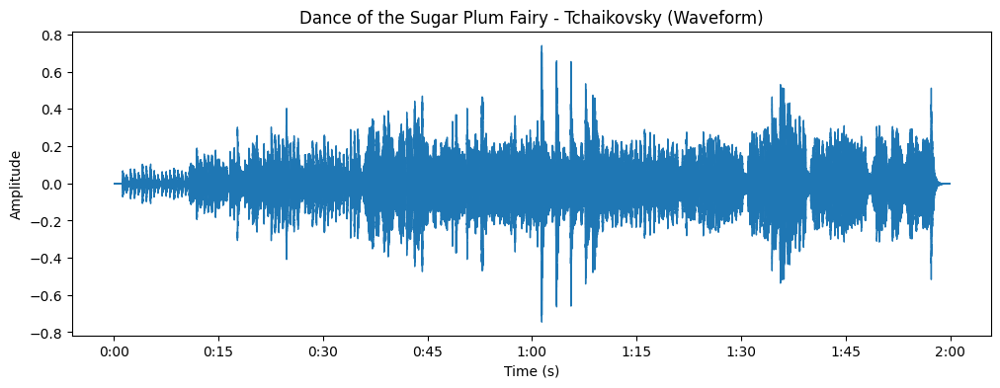

In [366]:
plt.figure(figsize=(12, 4))
plt.title('Dance of the Sugar Plum Fairy - Tchaikovsky (Waveform)')
librosa.display.waveshow(y=wave, sr=sr, axis='time')
plt.ylabel('Amplitude')
plt.xlabel('Time (s)')
plt.show()

## 2. Spectral Analysis: Time-Frequency Representation

To find unique characteristics in the audio, we convert the 1D time-domain waveform into a 2D time-frequency representation using the Short-Time Fourier Transform (STFT).

Since the STFT represents a complex 2D matrix, we compute its magnitude to retrieve the intensity of each frequency bin through time (represented in frames).

- For visualization purposes, we apply a logarithmic scale for ease of view. Notice that human hearing operates logarithmically, and this also visually normalizes the wide dynamic range of the audio. However, for the algorithm itself, we won't use the logarithmic scale, as seen in the following parts of this notebook.

In [367]:
stft = librosa.stft(wave)
stft_mag = np.abs(stft)

print(f'Shape of STFT: {stft.shape}')
print(f'Data type of STFT: {stft.dtype}')
print(f'Shape of STFT magnitude: {stft_mag.shape}')
print(f'Data type of STFT magnitude: {stft_mag.dtype}')

Shape of STFT: (1025, 5163)
Data type of STFT: complex64
Shape of STFT magnitude: (1025, 5163)
Data type of STFT magnitude: float32


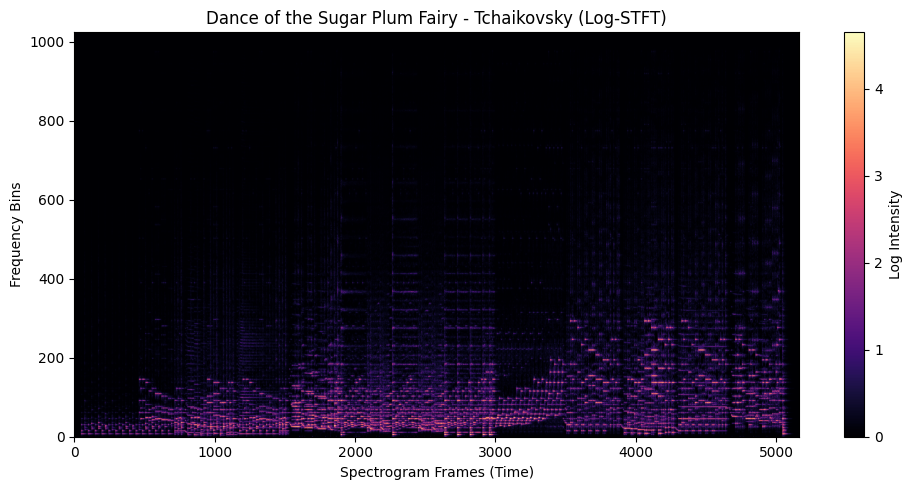

In [368]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Dance of the Sugar Plum Fairy - Tchaikovsky (Log-STFT)')

# np.log1p computes log(1 + x) to avoid log(0) errors
img = ax.imshow(np.log1p(stft_mag), cmap='magma', origin='lower', aspect='auto')

ax.set_xlabel('Spectrogram Frames (Time)')
ax.set_ylabel('Frequency Bins')
fig.colorbar(img, ax=ax, label='Log Intensity')
fig.tight_layout()
plt.show()

## 3. Extracting Constellation Maps

To make the algorithm fast and robust, we do not match raw audio or full spectrograms. Instead, we extract a "_constellation map_", i.e., the local energy peaks in the spectrogram.

To improve computational speed, we filter the spectrogram to retain only the first 128 frequency bins, which contain the most acoustic information of the music.

In [369]:
def create_constellation_map(stft, frequency_size=11, time_size=5, threshold=0.01):
    constellation_map = np.zeros_like(stft, dtype=bool)

    for f in range(0, stft.shape[0]):
        fmin = max(0, f - frequency_size)
        fmax = min(f + frequency_size + 1, stft.shape[0])  # +1 since Python's slice is [x, y)

        for t in range(0, stft.shape[1]):
            tmin = max(0, t - time_size)
            tmax = min(t + time_size + 1, stft.shape[1])  # +1 since Python's slice is [x, y)

            curr_mag = stft[f,t]
            curr_peak = np.max(stft[fmin:fmax, tmin:tmax])

            if (curr_mag == curr_peak) and (curr_peak > threshold):
                constellation_map[f,t] = True

    return constellation_map

In [370]:
filtered_stft_mag = stft_mag[:128, :]
cmap = create_constellation_map(filtered_stft_mag)

print('Shape of filtered STFT:', filtered_stft_mag.shape)
print('Shape of constellation map:', cmap.shape)

Shape of filtered STFT: (128, 5163)
Shape of constellation map: (128, 5163)


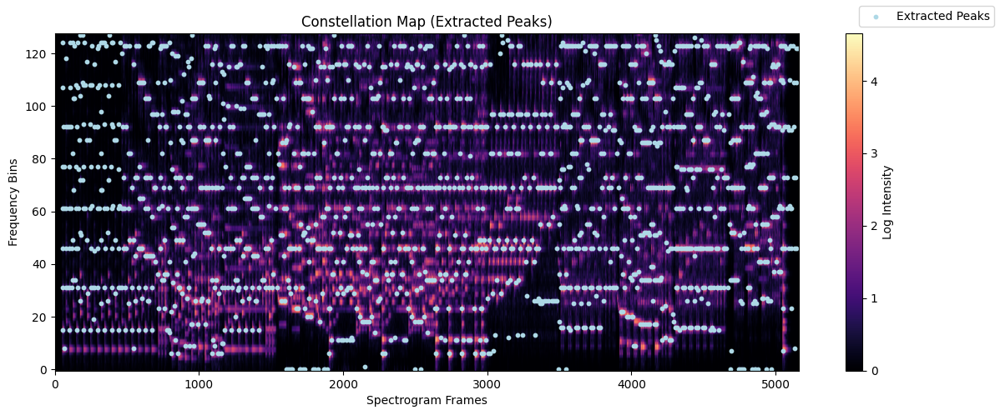

In [371]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Constellation Map (Extracted Peaks)')

img = ax.imshow(np.log1p(filtered_stft_mag), cmap='magma', origin='lower', aspect='auto')

peaks = np.where(cmap)
ax.scatter(peaks[1], peaks[0], color='lightblue', marker='o', s=10, label='Extracted Peaks')

ax.set_xlabel('Spectrogram Frames')
ax.set_ylabel('Frequency Bins')
fig.legend()
fig.colorbar(img, ax=ax, label='Log Intensity')
fig.tight_layout()
plt.show()

## 3.1 Robustness to Audio Degradation

A real-world query is never pristine. It is recorded through a microphone, compressed, and filled with background noise. Let's simulate a highly degraded "old smartphone" recording to ensure our constellation peaks survive.

For that, we will use a special Python library called [audiomentations](https://github.com/iver56/audiomentations), which provides a series of audio augmentations that can easily be used.

In [372]:
!pip install audiomentations --quiet
!pip install audiomentations[extras] --quiet

In [373]:
old_smartphone_pipeline = Compose([
    BandPassFilter(min_center_freq=1000.0, max_center_freq=2500.0, min_bandwidth_fraction=0.5, max_bandwidth_fraction=1.99, p=1.0),
    ClippingDistortion(min_percentile_threshold=10, max_percentile_threshold=30, p=1.0),
    Mp3Compression(min_bitrate=16, max_bitrate=48, backend="fast-mp3-augment", p=1.0),
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.0015, p=1.0)
])

In [374]:
# Generate the degraded audio
noisy_wave = old_smartphone_pipeline(samples=wave, sample_rate=sr)
ipd.display(ipd.Audio(data=noisy_wave, rate=sr))

In [375]:
noisy_stft = np.abs(librosa.stft(noisy_wave))[:128, :]
noisy_cmap = create_constellation_map(noisy_stft)

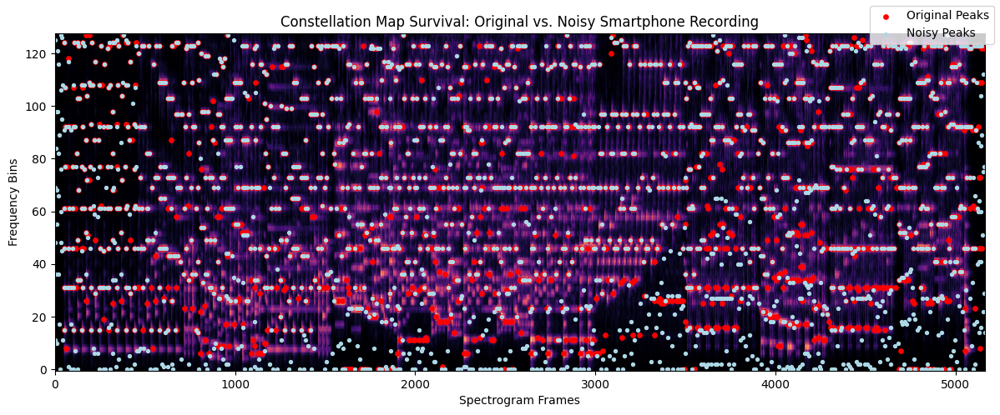

In [376]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Constellation Map Survival: Original vs. Noisy Smartphone Recording')

img = ax.imshow(np.log1p(filtered_stft_mag), cmap='magma', origin='lower', aspect='auto')

original_peaks = np.where(cmap)
ax.scatter(original_peaks[1], original_peaks[0], color='red', marker='o', s=15, label='Original Peaks')

noisy_peaks = np.where(noisy_cmap)
ax.scatter(noisy_peaks[1], noisy_peaks[0], color='lightblue', marker='o', s=8, label='Noisy Peaks')

ax.set_xlabel('Spectrogram Frames')
ax.set_ylabel('Frequency Bins')
fig.legend(loc='upper right')
fig.tight_layout()
plt.show()

### 3.1.1 What about effects that change the pitch and song speed?

In [377]:
from audiomentations import PitchShift, TimeStretch

In [378]:
custom_pipeline = Compose([
    TimeStretch(min_rate=1.10, max_rate=1.10, p=1.0),
    PitchShift(min_semitones=-1, max_semitones=-1, p=1.0)
])

custom_wave = custom_pipeline(samples=wave, sample_rate=sr)
ipd.display(ipd.Audio(data=custom_wave, rate=sr))

In [379]:
custom_stft = np.abs(librosa.stft(custom_wave))[:128, :]
custom_cmap = create_constellation_map(custom_stft)

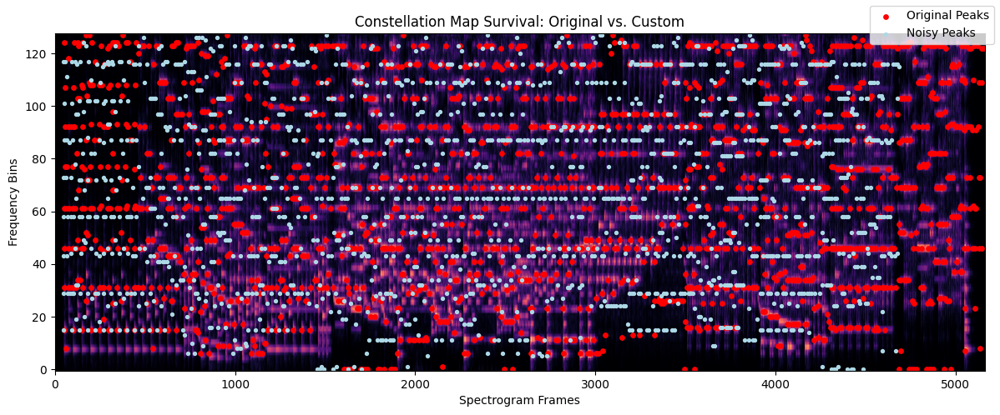

In [380]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Constellation Map Survival: Original vs. Custom')

img = ax.imshow(np.log1p(filtered_stft_mag), cmap='magma', origin='lower', aspect='auto')

original_peaks = np.where(cmap)
ax.scatter(original_peaks[1], original_peaks[0], color='red', marker='o', s=15, label='Original Peaks')

noisy_peaks = np.where(custom_cmap)
ax.scatter(noisy_peaks[1], noisy_peaks[0], color='lightblue', marker='o', s=8, label='Noisy Peaks')

ax.set_xlabel('Spectrogram Frames')
ax.set_ylabel('Frequency Bins')
fig.legend(loc='upper right')
fig.tight_layout()
plt.show()

# 4. Song Retrieval

Given a song query, for example the following excerpt from the used song example, how to retrieve which song is being played and what part of it corresponds to the query?

In [381]:
nutcracker_filename = librosa.example('nutcracker')
query_wave, sr = librosa.load(nutcracker_filename, sr=None, offset=60, duration=10)

# Optionally pass it through our old smartphone pipeline
query_wave = old_smartphone_pipeline(samples=query_wave, sample_rate=sr)

ipd.display(ipd.Audio(data=query_wave, rate=sr))

### 4.1 Sliding Window Naive Idea

One simple idea is to compute the query's constellation map and slide it through each song's database previously computed constellation map and look for a region with maximum number of matches.

The following represents this idea by sliding the query's constellation map thorugh the original song constellation map. The maximum match region should be using a frame offset of 2583 frames, which represents the 60 seconds mark used to generate the artificial query.

In [382]:
query_stft = np.abs(librosa.stft(query_wave))[:128, :]
query_cmap = create_constellation_map(query_stft)

In [383]:
@widgets.interact(
    frame_offset=widgets.IntSlider(min=0, max=filtered_stft_mag.shape[1], step=1, description='Frame Offset')
)
def sliding_window(frame_offset):
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.set_title('Sliding Window Naive Idea')
    img = ax.imshow(np.log1p(filtered_stft_mag), cmap='magma', origin='lower', aspect='auto')

    peaks = np.where(cmap)
    ax.scatter(peaks[1], peaks[0], color='red', marker='o', label='Original peaks')

    query_peaks = np.where(query_cmap)
    ax.scatter(frame_offset + query_peaks[1], query_peaks[0], color='lightblue', marker='o', s=5, label='Query peaks')

    ax.set_xlabel('Spectrogram Frames')
    ax.set_ylabel('Frequency Bins')

    fig.legend()
    fig.colorbar(img, ax=ax, label='Log Intesity')
    fig.tight_layout()

interactive(children=(IntSlider(value=0, description='Frame Offset', max=5163), Output()), _dom_classes=('widg…

## 4.2 Hashing: Combinatorial Pair Matching

Matching raw points is computationally expensive and fragile. Instead, we pair points together to form a "Hash": $\{f_1, f_2, \Delta t\}$.

By anchoring a point ($f_1$) and looking ahead into a specific target zone to find a second point ($f_2$), we record the time difference ($\Delta t$) between them. This relationship remains constant even if the audio is clipped from the middle of the song.

To be more realistic, we will use all of the example songs provided by librosa in the following [link](https://librosa.org/doc/latest/recordings.html#description-of-examples).

In [384]:
def generate_constellation_map_hashes(cmap, fzone_size, tzone_size, songname=None, sr=22050):
    """
    Generates combinatorial hashes from a constellation map for fast database lookups.
    """
    freqs, times = np.where(cmap)
    constellation_points = list(zip(freqs, times))

    # Sort chronologically to maintain a consistent forward-looking target zone
    constellation_points.sort(key=lambda x: x[1])
    times_only = [t for f, t in constellation_points]

    hashes = {}

    for (f, t) in constellation_points:
        # Define the target zone frequency boundaries
        tzone_fmin = max(0, f - fzone_size)
        tzone_fmax = min(cmap.shape[0], f + fzone_size)

        # Define the target zone time boundaries (looking forward in time)
        time_shift = t + 20
        tzone_tmin = max(0, time_shift - tzone_size)
        tzone_tmax = min(cmap.shape[1], time_shift + tzone_size)

        # Binary search (`bisect`) allows O(log N) lookup to find points within our time window
        start_idx = bisect.bisect_left(times_only, tzone_tmin)
        end_idx = bisect.bisect_right(times_only, tzone_tmax)

        # Iterate only over the points that fall inside the valid time window
        for i in range(start_idx, end_idx):
            target_f, target_t = constellation_points[i]

            # Ensure the target point also falls within the allowed frequency band
            if tzone_fmin <= target_f <= tzone_fmax:
                delta_time = target_t - t

                # Create the string hash: "freq1_freq2_deltatime"
                hash_key = f"{f}_{target_f}_{delta_time}"

                if hash_key not in hashes:
                    hashes[hash_key] = []

                # Store the absolute time of f1 to calculate offsets later
                hashes[hash_key].append((songname, float(librosa.frames_to_time(t, sr=sr))))

    return hashes

In [385]:
librosa_examples = [
    {
        "key": "brahms",
        "full_name": "Brahms - Hungarian Dance #5",
        "description": "A short performance of this piece, with soft note onsets and variable tempo."
    },
    {
        "key": "choice",
        "full_name": "Admiral Bob - Choice",
        "description": "A short drum and bass loop, good for demonstrating decomposition methods."
    },
    {
        "key": "fishin",
        "full_name": "Karissa Hobbs - Let's Go Fishin'",
        "description": "A folk/pop song with verse/chorus/verse structure and vocals."
    },
    {
        "key": "humpback",
        "full_name": "Humpback whale song",
        "description": "Glacier Bay 60-second clip of humpback whale song."
    },
    {
        "key": "libri1",
        "full_name": "Ashiel Mystery, A Detective Story, Ch. 2",
        "description": "LibriSpeech example, book narration by Garth Comira."
    },
    {
        "key": "libri2",
        "full_name": "The Age of Chivalry, Ch. 18: Perceval",
        "description": "LibriSpeech example, book narration by Anders Lankford."
    },
    {
        "key": "libri3",
        "full_name": "Sense and Sensibility, Ch. 18",
        "description": "LibriSpeech example, book narration by Heather Barnett."
    },
    {
        "key": "nutcracker",
        "full_name": "Tchaikovsky - Dance of the Sugar Plum Fairy",
        "description": "Orchestral piece included to demonstrate tempo and harmony features."
    },
    {
        "key": "pistachio",
        "full_name": "The Piano Lady - Pistachio Ice Cream Ragtime",
        "description": "Solo piano ragtime piece."
    },
    {
        "key": "robin",
        "full_name": "Bird Whistling, Robin",
        "description": "A single chirping call of an English robin bird."
    },
    {
        "key": "sweetwaltz",
        "full_name": "Setuniman - Sweet Waltz",
        "description": "3/4 time piece with synthetisized xylophone, flute, and organ."
    },
    {
        "key": "trumpet",
        "full_name": "Mihai Sorohan - Trumpet loop",
        "description": "Monophonic trumpet recording, good for demonstrating pitch features."
    },
    {
        "key": "vibeace",
        "full_name": "Kevin Macleod - Vibe Ace",
        "description": "A vibraphone, piano, and bass combo. Previously the only included example."
    }
]

In [386]:
db_hashes = {}

for example in tqdm(librosa_examples, desc='Creating database'):
    filename = librosa.example(example['key'])
    wave, sr = librosa.load(filename, sr=None)
    cmap = create_constellation_map(np.abs(librosa.stft(wave))[:128, :])

    db_hashes.update(generate_constellation_map_hashes(cmap, 15, 9, songname=example['full_name'], sr=sr))

Creating database:   0%|          | 0/13 [00:00<?, ?it/s]

In [387]:
print(f'Number of database hashes generated: {len(db_hashes)}')

Number of database hashes generated: 9596


### 4.2.1 Querying the database

The querying occurs basically by matching hashes and calculate the relative temporal offset ($\Delta T = T_{db} - T_{query}$). The correct song will have a massive spike of matching hashes at the exact same time offset.

In [388]:
query_hashes = generate_constellation_map_hashes(query_cmap, 15, 9, sr=sr)
print(f'Number of query hashes generated: {len(query_hashes)}')

Number of query hashes generated: 166


In [389]:
song_matches = {}

for query_hash_key, query_values in query_hashes.items():
    if query_hash_key in db_hashes:
        query_time = query_values[0][1]  # unpack the query time

        for db_songname, db_time in db_hashes[query_hash_key]:
            time_offset = db_time - query_time
            key = (db_songname, round(time_offset, 2))  # rounded offset to account for minor calculation drift

            if key not in song_matches:
                song_matches[key] = 0

            # Cast a vote for this specific song and time offset
            song_matches[key] += 1

if not song_matches:
    print("No matches found in the database.")
else:
    best_match = max(song_matches.items(), key=lambda x: x[1])
    winning_song, winning_offset = best_match[0]
    votes = best_match[1]

    print("--- MATCH RESULTS ---\n")
    print(f"Match found! Song: {winning_song}")
    print(f"Confidence (Aligned Points): {votes}")
    print(f"Time Offset: {winning_offset} seconds")

--- MATCH RESULTS ---

Match found! Song: Tchaikovsky - Dance of the Sugar Plum Fairy
Confidence (Aligned Points): 38
Time Offset: 60.0 seconds
